In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Very Short-term Forecasting Exercise using Keras & Tensorflow

We will try several algorithms to generate very short-term forecasters for power and load response of our Vestas V52 turbine.
<br> **Rated Power** $\rightarrow$ 850 kW
<br> **Structural Load Measurements** $\rightarrow$ 50 Hz strain gauge system
<br> **Flow measurements** $\rightarrow$ 2 & 4 beamed lidars 

 <img src="https://i.imgur.com/LOAsoRq.png" alt="Drawing" style="float: left; width: 1500px;" /> 

We will map the inflow measurements to turbine response, in a supervised learing setting, also accounting for the time it takes for the flow to 'hit' the turbine. See how much in forn of the turbines we are scanning with a lidar below:

 <img src="https://i.imgur.com/vygZx9y.png" alt="Drawing" style="float: left; width: 1500px;" /> 

The dataset contains synchronized measurements from the systems. The objective is to build a
model that takes only lidar measurements as inputs and forecast power and structural loads at the relevant
forecast horizons. The lidar measurements come in through Line of Sight (LOS) of their respective beams (2 vs. 4), providing different level of information. 

 <img src="https://i.imgur.com/q2ZrwSz.png" alt="Drawing" style="float: left; width: 1500px;" /> 


# First thing is to load the data 

Let's go pandas - watch for delimiter & 'non-data' text in the beginning

In [ ]:
import pandas as pd
dataset = pd.read_csv('.csv', 
                      delimiter=',',
                      parse_dates=[''],
                      index_col='')
dataset

## Visualization of the time-series is always helpful

Let's check what we have

In [ ]:
import matplotlib.pyplot as plt

dataset.plot(subplots=, figsize=(20,20))
plt.show()

## Field measurements are known to have many issues!

Missing data & time stamps are particularly a problem for forecasting as they require continuous information to build past and future relationship
We will need to be careful when creating our sequences!

In [ ]:
# Drop rows where index is NaT
dataset = dataset[~dataset.index.isna()]

In [ ]:
full_range = pd.date_range(start=dataset.index[0], 
                           end=dataset.index[-1], 
                           freq='') # What is the resolution of our dataset
mask = ~full_range.isin(dataset.index)
missing_time_stamps = full_range[mask]

missing_time_stamps

In [ ]:
dataset[dataset.index == pd.Timestamp(missing_time_stamps[0])]

In [ ]:
# Use 'asfreq' to get a continuous series with NaNs for missing rows

dataset_cont = dataset.resample('1s').asfreq()

# Identify rows where ALL features are NaN
all_nan_mask = dataset_cont.isna().all(axis=1)

# Count consecutive NaN rows using groupby
# Create groups of consecutive True/False values
nan_groups = (all_nan_mask != all_nan_mask.shift()).cumsum()

# Count consecutive NaNs in each group
consecutive_nan_counts = all_nan_mask.groupby(nan_groups).transform('sum')

# Define threshold: 1 day = 86400 seconds
max_consecutive_nans = 86400  # 1 day in seconds

# Keep rows where consecutive NaN count is below threshold OR row has data
keep_mask = (consecutive_nan_counts < max_consecutive_nans) | (~all_nan_mask)

# Apply the filter
dataset_cont = dataset_cont[keep_mask]

print(f"Original resampled length: {len(dataset.resample('1s').asfreq())}")
print(f"After removing long NaN gaps: {len(dataset_cont)}")

## Check the correlations within your data

Check cross-correlations between all features to see the relationships between lidar wind speed measurements, power, and structural load channel(s)!

Cross correlations are great to:
* See potential dependencies between variables
* Identify which features may improve model performance
* Check if there is any redundant data



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute cross-correlation matrix
corr_matrix = dataset_cont.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Cross-Correlation Matrix of our data for Lidar Power/Load Forecasting')
plt.tight_layout()
plt.show()


# Divide Time series into Sequences

<img src="https://i.ibb.co/Htb5S60/Sequence-sliding-faster.gif" alt="Drawing" style="float: left" /> 
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
We will define 2 useful functions that will generate sequences of input + output intervals.

* The input interval is based on how much further back you would like to add to the memory
* The output interval depends on the forecast horizon for your problem


In [ ]:
### define a function that will prepare the shifting input sequences for the network
def forecast_sequences_input(input_data,n_lag):
    """
    A function that will split the input time series to sequences for nowcast/forecast problems
    Arguments:
        input_data: Time series of input observations as a list, NumPy array or pandas series
        n_lag: number of previous time steps to use for training, a.k.a. time-lag        
    Returns:
        Pandas DataFrame of series framed for supervised learning.
    """
    n_vars = input_data.shape[1] 
    df = pd.DataFrame(input_data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_lag, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together (aggregate)
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    return agg


### define a function that will prepare the shifting output sequences of the network
def forecast_sequences_output(output_data,n_out):
    """
    A function that will split the output time series to sequences for nowcast/forecast problems
    Arguments:
        output_data: Time series of input observations as a list, NumPy array or pandas series
        n_out: forecast horizon (for multi-output forecast)
    Returns:
        Pandas DataFrame of series framed for supervised learning.
    """
    n_vars = output_data.shape[1] 
    df = pd.DataFrame(output_data)
    cols, names = list(), list()
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together (aggregate)
    agg = pd.concat(cols, axis=1)
    agg.columns = names    
    return agg


# Forecasting with the 2-beam lidar

In our forecasting problem, we have different input-output sequences and different horizons per lidar type
* What are the relevant inputs for the 2-beam lidar?
* What should be the output horizon?

The input interval is one of the *hyperparameters* to tune. We can start with an initial guess and adjust it to see if we can get a performance increase.

So we can argue that the choice of a meaningful input interval is a **data-science** problem, whereas a meaningful forecasting horizon would be a **domain-specific** choice :)


## 2-beam Inputs & Outputs

INPUTS:   
   1. Line of Sight Wind Speeds $\rightarrow$ `W2_Vlos1_orig`, `W2_Vlos2_orig`

In [ ]:
# input channels
input_ch = ['','']

# input matrix
X = dataset_cont[input_ch]

# input interval
n_lag = 

# input sequences
X_seq = forecast_sequences_input(X, n_lag)

X_seq

OUTPUTS:
   1. Turbine Power $\rightarrow$ `ActPow`  
   2. Blade root Flap-wise bending moment $\rightarrow$ `MxC1_auto`

**In terms of potential model accuracy, would you go for a single or multiple output configuration for your forecaster?** 

In [ ]:
import numpy as np

# output channels
output_ch = ['','']

# output matrices
Y1 = dataset_cont[[output_ch[0]]] # turbine power
Y2 = dataset_cont[[output_ch[1]]] # blade root flap-wise bending moment 

# output interval / forecast horizon
"""
Can be estimated via the time it takes for the flow to reach the turbine
2-beam lidar scans 32m in front
"""
n_out = 32 / np.nanmedian(dataset_cont['W2_Vlos1_orig'])
n_out = round(n_out)

print(str(n_out)+" steps ahead sequences & forecasting!") 

# output sequences
Y1_seq = forecast_sequences_output(Y1, n_out)
Y2_seq = forecast_sequences_output(Y2, n_out)

Y1_seq

## Simple Baseline: Persistence Forecasts

The **persistence forecast** is a critical benchmark for evaluating time series forecasting models, especially for **very short-term predictions**. It simply predicts that the next value(s) will be the same as the most recent observation.

For wind power and load forecasting with short prediction horizons (seconds to minutes), persistence forecasts often perform surprisingly well due to the strong autocorrelation in these signals. Wind speed and power don't change drastically from one second to the next, making simple persistence a tough baseline to beat.

**Why persistence matters:**

- **Reality check**: To see if your neural network model performs worse than persistence
- **Establishes performance floor**: Any model should outperform this trivial baseline
- **Short-term advantage**: Persistence is particularly strong for very short forecasting horizons (< 10 minutes), making it harder to demonstrate model value
- **Benchmark for improvement**: Quantifies how much your model actually learns beyond simple temporal continuity

For wind energy applications, studies show that persistence often outperforms more complex models for **lead times under 5-10 minutes**. This underscores why features like LIDAR wind measurements (which provide spatial and temporal lookahead) are valuable—they help overcome the persistence baseline by introducing predictive information about upcoming wind conditions.

Always compare your model performance against persistence to ensure you're adding real forecasting value.


In [ ]:
# Creating the persistence forecast
# For each timestep, predict that all n_out future values equal the last observation
Y1_pers = Y1.shift(periods=1).values

# Use the LAST value of the input sequence as the forecast for ALL future timesteps
Y1_pers = np.tile(Y1_pers, n_out)

Y2_pers = Y2.shift(periods=1).values
Y2_pers = np.tile(Y2_pers, n_out)

Y1_pers

In [ ]:
Y1_seq

## Handling NaNs

NaN values in sequences can corrupt model training if not handled properly. We address them differently for FFNNs and RNNs:
* **FFNN (Feed-Forward Neural Networks)**: Typically require complete data—sequences with NaNs must be removed entirely or imputed before training
* **RNNs (Recurrent Neural Networks (e.g., LSTMs, GRUs)**: Can learn temporal patterns through padding and masking, allowing selective NaN handling within sequences
* **For both, regarding Output Features**: Missing ground truth (power, load) typically requires removal of entire sequences, as models cannot learn from unknown targets



In [ ]:
# Removing NaNs from both input and output for FFNN

# Check for NaNs in inputs (X_seq)
idx_X = (np.isnan(X_seq).any(axis=1))

# Check for NaNs in outputs
idx1 = (np.isnan(Y1_seq).any(axis=1))
idx2 = (np.isnan(Y2_seq).any(axis=1))

# Check for NaNs in persistence forecasts
idx1_pers = (np.isnan(Y1_pers).any(axis=1))
idx2_pers = (np.isnan(Y2_pers).any(axis=1))

# Combine all NaN indices (remove if ANY sequence has NaNs)
idx_to_remove = idx_X | idx1 | idx1_pers  # for output 1
idx_to_remove2 = idx_X | idx2 | idx2_pers  # for output 2

# Remove sequences with NaNs for output 1
Y1_seq = Y1_seq.iloc[~idx_to_remove.values, :]
X1_seq = X_seq.iloc[~idx_to_remove.values, :]
Y1_pers = Y1_pers[~idx_to_remove.values]

# Remove sequences with NaNs for output 2
Y2_seq = Y2_seq.iloc[~idx_to_remove2.values, :]
X2_seq = X_seq.iloc[~idx_to_remove2.values, :]
Y2_pers = Y2_pers[~idx_to_remove2.values]

print(f"Final X1/Y1 sequences: {len(X1_seq)}")
print(f"Final X2/Y2 sequences: {len(X2_seq)}")


---

## ☕ Coffee Break

Even data scientists need a break.

![Coffee Break](https://user-gen-media-assets.s3.amazonaws.com/seedream_images/9c4219e5-020a-40bc-bd6c-a8c5b6e814e0.png)

---


## Train/Validation Split for Time Series Forecasting

For time series forecasting, random or stratified sampling breaks temporal dependencies, which is critical to avoid. Instead, use temporal splitting strategies that respect chronological order.

You can split data at a specific time point—train on earlier data, validate on later data - but it creates seasonal bias for wind energy forecasting! Instead, group time series by temporal strata (e.g., hour-of-day, day-of-week, season) to make sure you train and validate all year long!

For a robust performance, you can try a temporal definition to `stratify` the [scikit learn `StratifiedShuffleSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html)

We will 'stratify' the data into temporal groups as:
* hours into 4 time blocks: night, morning, afternoon, evening
* the month within the year

Within each strata, we will use 80% of the samples for training and 20% of the samples for validation


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# Extract timestamps from the index of our sequences
timestamps = X1_seq.index

# Extract temporal features for stratification
hour_of_day = timestamps.hour  # 0-23
month = timestamps.month  # 1-12

# Group hours into 4 time blocks
def hour_to_block(hour):
    if 0 <= hour < :
        return 'night'
    elif 6 <= hour < :
        return 'morning'
    elif 12 <= hour < :
        return 'afternoon'
    else:  # 18 <= hour < 24
        return 'evening'

time_block = hour_of_day.map(hour_to_block)

# Create stratification groups
temporal_strata = (
                    time_block.astype(str) + '_' + 
                    month.astype(str)
                  )

print(f"Unique temporal strata: {len(np.unique(temporal_strata))}")

# Use StratifiedShuffleSplit to get indices 
sss = StratifiedShuffleSplit(
                             n_splits=1, # =1 for no-shuffling
                             train_size=, # XX% for training
                             random_state=42 # for reproducibility
                            )

# Get train and validation indices
for train_idx, val_idx in sss.split(np.zeros(len(X1_seq)), temporal_strata):
    # Convert DataFrames to numpy and split using indices
    X1_train = X1_seq.values[train_idx]
    X1_val = X1_seq.values[val_idx]
    Y1_train = Y1_seq.values[train_idx]
    Y1_val = Y1_seq.values[val_idx]
    
    X2_train = X2_seq.values[train_idx]
    X2_val = X2_seq.values[val_idx]
    Y2_train = Y2_seq.values[train_idx]
    Y2_val = Y2_seq.values[val_idx]

print(f"Training samples: {len(X1_train)}")
print(f"Validation samples: {len(X1_val)}")
print(f"Split ratio: {len(X1_train)/(len(X1_train)+len(X1_val))*100:.1f}% / {len(X1_val)/(len(X1_train)+len(X1_val))*100:.1f}%")


### Let's clear up some memory

In [ ]:
import gc

# Delete large arrays you no longer need
del dataset

# Force garbage collection
gc.collect()

## Scale (or Normalize) the data

It is very important for our problem that the inputs are normalised. This is mainly due to the fact that our features might have different 'value ranges' or scales. Not scaling the data beforehand might cause inefficient weights and bias in our learning.

To be able to estimate the weights and biases properly for our model, we need to normalise all the inputs and ouputs. Here, we chose to scale our data between -1 and 1 and we will use scikit-learn preprocessing library for that. Using scikit-learn (or manually scaling the data), feel free to try out other methodologies. This is another 'hyperparameter' if you will...

After scaling, printing the scaled data shows the considered values are rather similar now.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

X1scaler = MinMaxScaler(feature_range=(-1,1))
X1_train_scaled = X1scaler.fit_transform(X1_train)
X1_val_scaled = X1scaler.transform(X1_val)

X2scaler = MinMaxScaler(feature_range=(-1,1))
X2_train_scaled = X2scaler.fit_transform(X2_train)
X2_val_scaled = X2scaler.transform(X2_val)

Y1scaler = MinMaxScaler(feature_range=(-1,1))
Y1_train_scaled = Y1scaler.fit_transform(Y1_train)
Y1_val_scaled = Y1scaler.transform(Y1_val)

Y2scaler = MinMaxScaler(feature_range=(-1,1))
Y2_train_scaled = Y2scaler.fit_transform(Y2_train)
Y2_val_scaled = Y2scaler.transform(Y2_val)


X1_train_scaled

# Define the Model to train

We create a Sequential, feed-forward model and add layers one at a time until we are happy with our network topology.

The first thing to get right is to ensure the input layer has the right number of inputs. We can specify that when creating the first layer with the input_dim argument and setting to the number of our input variables.

![FFNN Diagram](https://i.ibb.co/MRFKXzc/Cn-P-31102024-175304.png)

### How do we know the 'best' number of layers and their types?

This is a very hard question. There are heuristics that we can use and often the best network structure is found through a process of trial and error experimentation. Generally speaking, you need a network large enough to capture the structure of the problem. 

In this example, we will use a **fully-connected network structure with 2 hidden layers and an output layer**, to begin with.

Fully connected layers are defined using the Dense class. We can specify the number of neurons in the layer as the first argument, the initialization method as the second argument as init and specify the activation function using the activation argument.

### Initialization of Weights and Biases
The initalization for the weights and biases (as all the features of Keras) is well documented here: [https://keras.io/initializers/](https://keras.io/initializers/) 
<br>In our case, we initialize the network weights using **`glorot_uniform`** (Xavier uniform initialization), which is designed to maintain appropriate variance across layers. This initializer works particularly well with modern smooth activation functions like GELU, SiLU, and Mish. An alternative would be `'he_normal'` (Kaiming normal) for slightly more aggressive initialization, or the traditional `'normal'` for small random numbers generated from a Gaussian distribution. Biases are typically initialized to zeros.


### Activation Functions
When we do not have the activation function the weights and bias would simply do a linear transformation. A linear equation is simple to solve but is limited in its capacity to solve complex problems. The activation function does the non-linear transformation to the input making it capable to learn and perform more complex tasks.

There are many activation functions available in Keras https://keras.io/activations/. 
The most-widely used ones are listed below:

   1. **sigmoid** $\rightarrow$ logistic & non-linear 
<br> 

<img src="https://cdn-images-1.medium.com/max/1600/1*Xu7B5y9gp0iL5ooBj7LtWw.png" alt="Drawing" style="float: left; width: 300px;" />

As seen, the sigmoid function is defined between (0 to 1). Accordingly, it is especially useful for probability prediction/modelling.Since probability of anything exists only between the range of 0 and 1, sigmoid is the right choice where probability is the output. However, the logistic sigmoid function can cause a neural network to get stuck at the training time.
Therefore, softmax function is a more generalized logistic activation function which is used for multiclass classification.
<br>
<br>
<br>
<br>
  <br>2. **softmax** $\rightarrow$ generalization of the logistic function
  
<img src="https://cdn.botpenguin.com/assets/website/Softmax_Function_07fe934386.png" alt="Drawing" style="float: left; width: 250px;" /> 

Similar to Sigmoid, the calculated probabilities via Softmax function will be in the range of 0 to 1. Additionally, Softmax assembles actual classes to 1 - ensures that the sum of all the probabilities is equal to 1. For more detailed explanation on sigmoid and softmax, including their mathematical representations, see https://themaverickmeerkat.com/2019-10-23-Softmax/
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
   <br>3. **tanh** $\rightarrow$ non-linear, also covers negative range    
 <img src="https://i2.wp.com/sefiks.com/wp-content/uploads/2017/01/tanh.png?resize=456%2C300&ssl=1" alt="Drawing" style="float: left; width: 300px;" /> 

tanh is also sigmoidal (s - shaped) but the range of the tanh function is from (-1 to 1). That enables to map negative inputs as well. The tanh function is mainly used for classification problems between two classes. 
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
   <br>4. **relu (Rectified Linear Unit)** $\rightarrow$ also non-linear, also covers negative range   
<img src="https://www.researchgate.net/profile/Leo-Pauly/publication/319235847/figure/fig3/AS:537056121634820@1505055565670/ReLU-activation-function.png" alt="Drawing" style="float: left; width: 200px;" /> 
 
As seen, ReLU is half rectified (from bottom). f(x) is zero when for negative x and f(x) is equal to x when x is above or equal to zero. The function has a range from 0 to infitinity.

Mainly due to its computational simplicity, ReLu is the most used activation function today. However, it risks to produce "dead neurons" because of the range with output 0. In other words, it is challenging to map the negative inputs with ReLu activation function appropriately.
<br>
<br>
<br>
<br>

<br>5. **LeakyReLu** $\rightarrow$ still non-linear, still covers negative range, prevents dead neurons   
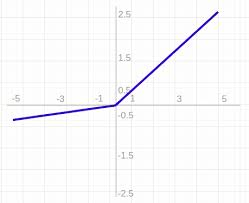 

As seen, the leak helps to increase the range of the ReLU function. Usually, the value of $a_i$ is 0.01 or so. The function has a range from -$\infty$ to $\infty$...

When $a_i$ is not 0.01 then it is called **Randomized ReLU**. .
<br>
<br>
<br>
<br>
<br>
<br>
<br>6. **GELU (Gaussian Error Linear Unit)** $\rightarrow$ smooth non-linear, modern activation with probabilistic behavior

<img src="https://user-gen-media-assets.s3.amazonaws.com/seedream_images/105ce266-75fe-4278-a7b9-08e9f1f71a34.png" alt="GELU" style="float: left; width: 200px;" />

GELU is a smooth approximation to ReLU that multiplies inputs by the cumulative distribution function of a Gaussian. Unlike ReLU's sharp cutoff at zero, GELU provides a smooth, probabilistic transition. The range is from -$\infty$ to $\infty$.

GELU has become the standard activation function in modern transformer-based architectures (BERT, GPT, Vision Transformers) and provides smoother gradient flow during backpropagation.
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>7. **SiLU (Sigmoid Linear Unit) / Swish** $\rightarrow$ self-gated smooth activation, non-monotonic

<img src="https://user-gen-media-assets.s3.amazonaws.com/seedream_images/2bcd5e90-f54c-41e1-b55d-d1e655ce7797.png" alt="SiLU" style="float: left; width: 200px;" />

SiLU (also called Swish) is essentially input times sigmoid function. It weighs the importance of each input adaptively. The function smoothly transitions through zero and exhibits non-monotonic behaviour. The range is from -$\infty$ to $\infty$.

Swish was developed by Google Brain and shows improvements in benchmarks when replacing ReLU. It provides smoother gradients than ReLU and is particularly useful in tasks requiring fine-grained adaptivity. SiLU is now widely used in modern architectures.
<br>
<br>
<br>
<br>
<br>
<br>

In the earlier deep learning applications, sigmoid and tanh activation functions were preferred for all layers. Then rectifier activation function (**‘relu‘**) is reported to have better performance. Nowadays, it is generally recommended  to start with Relu (or LeakyRelu if you're after the gradients of your model or GELU if you would also like to have a smooth transition - GELU has become the modern standard) as the activation function, for the input and the hidden layers. For the output layer, the activation depends on the task. For a classifier, sigmoid and softmix makes sense as described earlier. But remember, trial & error is always valid as well :)  

We can piece it all together by adding each layer. The first layer has XX neurons and expects 2 input variables. The second hidden layer has YY neurons and finally, the output layer has the forecast horizon for number of neurons to predict the 'future'.

# Power Forecaster - Model1: FFNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow.keras.backend as K

# for multiple model creation - clear  the previous DAG
K.clear_session() 

# create model - feel free to change the number of neurons per layer
model1 = Sequential()

model1.add(Dense(, 
                input_dim=X1_train_scaled.shape[1], 
                kernel_initializer='glorot_uniform',
                bias_initializer='zeros',
                activation='gelu'))

model1.add(Dense(, 
                kernel_initializer='glorot_uniform',
                activation='gelu'))

model1.add(Dense(n_out))

model1.summary()

## Compile Model

Now that the model is defined, we can compile it.

Compiling the model in Keras use TensorFlow as the execution engine, under the covers. The Tensorflow backend automatically chooses the best way to represent the network for training and making predictions to run on your hardware, such as CPU, GPU, etc.

When compiling, we must specify some additional properties required when training the network. Remember, training a network means finding the best set of weights (and biases) to make predictions for this problem.

1. **loss function:** We must specify the loss function to optimise and train the (weights and biases of the) model. It calculates how far the model's predictions deviate from the actual values and is minimised during training. There are quite a number of available loss functions embedded in tf.keras https://www.tensorflow.org/api_docs/python/tf/keras/losses

Recent developments in loss functions for time series forecasting:

* Patch-wise Structural (PS) Loss (2025): Measures local structural similarity instead of point-wise errors, capturing temporal dependencies better than MSE

* Decomposition-Based Loss (DBLoss) (2025): Decomposes time series into trend and seasonal components, calculating loss separately for each

* Signal Decay-Based Loss: Weights near-future predictions more heavily than far-future ones, as errors increase with prediction horizon

These advanced loss functions can improve forecasting accuracy beyond traditional MSE, especially for capturing complex temporal patterns.


2. **optimizer:** The optimizer used to search through different weights for the network and any optional metrics we would like to collect and report during training. The available optimizers within tf.keras are listed here https://www.tensorflow.org/api_docs/python/tf/keras/optimizers The optimizer or the gradient descent optimizer is an important hyperparameter that essentially tells in which direction we should update each weight. The Keras documentation is quite extensive, also equipped with external references if you are interested in reading more. 
For the recurrent neural networks, it is generally recommended to use **'adam'** or **'RMSprop'**. Together with **'adagrad'**, they are so-called "adaptive optimizers", as they support **adaptive learning rates**. Too small learning rate can cause slow learning and the optimizer to get stuck. Whereas too large learning rate can cause the model to converge too quickly to a suboptimal solution. Adaptive learning rates can accelerate training and alleviate some of the pressure of choosing a learning rate and learning rate schedule. 

Adam remains robust for general deep learning and works well out-of-the-box with minimal tuning

3. **metrics:** Metrics are used to evaluate and judge the overall performance of the model. They don't affect the training process but provide a way to assess how well the model is doing. Therefore, they are optional to add to the setup - have a look at the options that are pre-coded in keras https://www.tensorflow.org/api_docs/python/tf/keras/metrics

Common metrics for forecasting include MAE (Mean Absolute Error), RMSE (Root Mean Square Error), MAPE (Mean Absolute Percentage Error), and R² score.


In [ ]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam

model1.compile(loss='mean_absolute_error', 
              optimizer=Adam(learning_rate=0.01),
              metrics=[metrics.RootMeanSquaredError(name='rmse')])

## Fit the Model 

We have defined our model and compiled it so it is ready for efficient computation :)

Now it is time to execute the model on our data.

We can train or fit the weights of our model on our loaded data by calling the fit() function on the model.

The training process will run for a fixed number of iterations through the dataset called epochs, that we must specify using the epochs argument. We can also set the number of instances that are evaluated before a weight update in the network is performed, called the **batch size** and set using the batch_size argument. In general, a *wider model* refers to a higher number of neurons in the hidden layer, and a *deeper model* corresponds to more hidden layers in the model structure. Increasing number of epochs would mean training the model to its 'full potential', however, the convergence becomes significantly slower and the model might learn 'too much' from the training dataset that can lead to overfit.

For this problem, we will run for a small number of iterations (e.g. **epochs < thousands**) and use a reasonable batch size of (e.g. **batch_size << number of samples we have**). Again, these can be adjusted via a systematic grid search. In addition, we are adding a verbose argument which could be 0, 1, or 2; where 
1. **verbose=0** $\rightarrow$ silent (no progress on the convergence is printed), 
2. **verbose=1** $\rightarrow$ prints the progress bar,
3. **verbose=2** $\rightarrow$ one line loss on training and validation dataset and validation accuray is printed per epoch.

In [ ]:
history = model1.fit(X1_train_scaled, Y1_train_scaled, 
                    epochs= , 
                    batch_size= ,
                    verbose=2,
                    validation_data=(X1_val_scaled, Y1_val_scaled))

### plot history
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Train MAE')
plt.plot(history.history['val_loss'], label='Validation MAE')

plt.plot(history.history['rmse'], label='Train RMSE')
plt.plot(history.history['val_rmse'], label='Validation RMSE')

plt.title('Model Performance: MAE and RMSE')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()
plt.show()

---

## ☕ Coffee Break

Your model will still be there when you get back (probably still training).

![Coffee Break](https://user-gen-media-assets.s3.amazonaws.com/seedream_images/9c4219e5-020a-40bc-bd6c-a8c5b6e814e0.png)


---


## Use the Model - Perform Predictions

Scale back via `inverse_transform` from numerical realm --> physical values

In [ ]:
## Model Performance Evaluation

# Make predictions on validation set
Y1_pred_scaled = model1.predict()

# Inverse transform to get predictions in original scale
Y1_pred = Y1scaler.inverse_transform()
Y1_val_original = Y1scaler.inverse_transform(Y1_val_scaled)

# Also get persistence forecast for the same validation indices
Y1_pers_val = Y1_pers[val_idx]

## Define your metrics & visualise the performance

Here we use the classics 

In [ ]:
# Calculate overall metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_model = mean_absolute_error(Y1_val_original, Y1_pred)
rmse_model = np.sqrt(mean_squared_error(Y1_val_original, Y1_pred))
r2_model = r2_score(Y1_val_original, Y1_pred)

mae_pers = mean_absolute_error(Y1_val_original, Y1_pers_val)
rmse_pers = np.sqrt(mean_squared_error(Y1_val_original, Y1_pers_val))
r2_pers = r2_score(Y1_val_original, Y1_pers_val)

# Calculate Mean Bias Error (MBE) - shows over/under prediction
mbe_model = np.mean(Y1_pred - Y1_val_original)
mbe_pers = np.mean(Y1_pers_val - Y1_val_original)

# Calculate Mean Percentage Error (MPE) - shows systematic bias as percentage
mpe_model = np.mean((Y1_pred - Y1_val_original) / Y1_val_original) * 100
mpe_pers = np.mean((Y1_pers_val - Y1_val_original) / Y1_val_original) * 100


# Print results
print("=" * 75)
print("VALIDATION SET PERFORMANCE - Active Power Forecasting")
print("=" * 75)
print(f"\n{'Metric':<20} {'Model':<15} {'Persistence':<15} {'Improvement':<15}")
print("-" * 75)
print(f"{'MAE (kW)':<20} {mae_model:<15.2f} {mae_pers:<15.2f} {(1-mae_model/mae_pers)*100:>13.1f}%")
print(f"{'RMSE (kW)':<20} {rmse_model:<15.2f} {rmse_pers:<15.2f} {(1-rmse_model/rmse_pers)*100:>13.1f}%")
print(f"{'R² Score':<20} {r2_model:<15.3f} {r2_pers:<15.3f} {'-':<15}")
print("-" * 75)
print(f"{'MBE (kW)':<20} {mbe_model:<15.2f} {mbe_pers:<15.2f} {'-':<15}")
print(f"{'MPE (%)':<20} {mpe_model:<15.2f} {mpe_pers:<15.2f} {'-':<15}")
print("=" * 75)
print("\nBias Interpretation:")
print(f"  Model: {'OVER-predicting' if mbe_model > 0 else 'UNDER-predicting'} by {abs(mbe_model):.2f} kW ({abs(mpe_model):.2f}%)")
print(f"  Persistence: {'OVER-predicting' if mbe_pers > 0 else 'UNDER-predicting'} by {abs(mbe_pers):.2f} kW ({abs(mpe_pers):.2f}%)")
print("=" * 75)

# Calculate error per forecast horizon
mae_per_horizon_model = []
mae_per_horizon_pers = []
rmse_per_horizon_model = []
rmse_per_horizon_pers = []

for horizon in range(n_out):
    # MAE for each horizon
    mae_model_h = mean_absolute_error(Y1_val_original[:, horizon], Y1_pred[:, horizon])
    mae_pers_h = mean_absolute_error(Y1_val_original[:, horizon], Y1_pers_val[:, horizon])
    mae_per_horizon_model.append(mae_model_h)
    mae_per_horizon_pers.append(mae_pers_h)
    
    # RMSE for each horizon
    rmse_model_h = np.sqrt(mean_squared_error(Y1_val_original[:, horizon], Y1_pred[:, horizon]))
    rmse_pers_h = np.sqrt(mean_squared_error(Y1_val_original[:, horizon], Y1_pers_val[:, horizon]))
    rmse_per_horizon_model.append(rmse_model_h)
    rmse_per_horizon_pers.append(rmse_pers_h)

# Plot error growth per forecast horizon
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MAE per horizon
axes[0].plot(range(1, n_out+1), mae_per_horizon_model, 'o-', label='Model', linewidth=2, markersize=6)
axes[0].plot(range(1, n_out+1), mae_per_horizon_pers, 's--', label='Persistence', linewidth=2, markersize=6, alpha=0.7)
axes[0].set_xlabel('Forecast Horizon (seconds ahead)')
axes[0].set_ylabel('MAE (kW)')
axes[0].set_title('MAE Growth with Forecast Horizon')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE per horizon
axes[1].plot(range(1, n_out+1), rmse_per_horizon_model, 'o-', label='Model', linewidth=2, markersize=6)
axes[1].plot(range(1, n_out+1), rmse_per_horizon_pers, 's--', label='Persistence', linewidth=2, markersize=6, alpha=0.7)
axes[1].set_xlabel('Forecast Horizon (seconds ahead)')
axes[1].set_ylabel('RMSE (kW)')
axes[1].set_title('RMSE Growth with Forecast Horizon')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize predictions vs actual
plt.figure(figsize=(15, 5))

# Plot a subset of predictions (first XX timesteps or less if fewer available)
XX = 10
n_plot = min(XX, len(Y1_val_original))
plt.plot(Y1_val_original[:n_plot, 0], label='Actual', linewidth=2, alpha=0.7)
plt.plot(Y1_pred[:n_plot, 0], label='Model Prediction', linewidth=1.5, alpha=0.7)
plt.plot(Y1_pers_val[:n_plot, 0], label='Persistence', linewidth=1, alpha=0.5, linestyle='--')

plt.title('Active Power Forecast: Model vs Persistence vs Actual (1s ahead)')
plt.xlabel('Time Step')
plt.ylabel('Active Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot: Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(Y1_val_original[:, 0], Y1_pred[:, 0], alpha=0.3, s=10)
plt.plot([Y1_val_original.min(), Y1_val_original.max()], 
         [Y1_val_original.min(), Y1_val_original.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.title(f'Model Predictions (R²={r2_model:.3f}, MPE={mpe_model:.2f}%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(Y1_val_original[:, 0], Y1_pers_val[:, 0], alpha=0.3, s=10, color='orange')
plt.plot([Y1_val_original.min(), Y1_val_original.max()], 
         [Y1_val_original.min(), Y1_val_original.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Power (kW)')
plt.ylabel('Persistence Power (kW)')
plt.title(f'Persistence Baseline (R²={r2_pers:.3f}, MPE={mpe_pers:.2f}%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Load Forecaster - Model2: FFNN

We will follow the same steps as the power forecaster, including its architecture.
This time in a single cell:

In [ ]:
# for multiple model creation - clear  the previous DAG
K.clear_session() 

# create model - feel free to change the number of neurons per layer
model2 = Sequential()

model2.add(Dense(, 
                input_dim=X2_train_scaled.shape[1], 
                kernel_initializer='glorot_uniform',
                bias_initializer='zeros',
                activation='gelu'))

model2.add(Dense(, 
                kernel_initializer='glorot_uniform',
                activation='gelu'))

model2.add(Dense(n_out))

model2.summary()

model2.compile(loss='mean_absolute_error', 
              optimizer=Adam(learning_rate=0.01),
              metrics=[metrics.RootMeanSquaredError(name='rmse')])

history = model2.fit(X2_train_scaled, Y2_train_scaled, 
                    epochs=30, 
                    batch_size=32,
                    verbose=2,
                    validation_data=(X2_val_scaled, Y2_val_scaled))

### plot history
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Train MAE')
plt.plot(history.history['val_loss'], label='Validation MAE')

plt.plot(history.history['rmse'], label='Train RMSE')
plt.plot(history.history['val_rmse'], label='Validation RMSE')

plt.title('Model Performance: MAE and RMSE')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()
plt.show()

## Model Performance Evaluation

# Make predictions on validation set
Y2_pred_scaled = model2.predict(X2_val_scaled)

# Inverse transform to get predictions in original scale
Y2_pred = Y2scaler.inverse_transform(Y2_pred_scaled)
Y2_val_original = Y2scaler.inverse_transform(Y2_val_scaled)

# Also get persistence forecast for the same validation indices
Y2_pers_val = Y2_pers[val_idx]

# Remove NaNs from persistence forecast and align all arrays
valid_mask = ~np.isnan(Y2_pers_val).any(axis=1)

Y2_val_original = Y2_val_original[valid_mask]
Y2_pred = Y2_pred[valid_mask]
Y2_pers_val = Y2_pers_val[valid_mask]

print(f"Samples after removing NaNs: {len(Y2_val_original)} / {len(Y2scaler.inverse_transform(Y2_val_scaled))}")

# Calculate overall metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_model = mean_absolute_error(Y2_val_original, Y2_pred)
rmse_model = np.sqrt(mean_squared_error(Y2_val_original, Y2_pred))
r2_model = r2_score(Y2_val_original, Y2_pred)

mae_pers = mean_absolute_error(Y2_val_original, Y2_pers_val)
rmse_pers = np.sqrt(mean_squared_error(Y2_val_original, Y2_pers_val))
r2_pers = r2_score(Y2_val_original, Y2_pers_val)

# Calculate Mean Bias Error (MBE) - shows over/under prediction
mbe_model = np.mean(Y2_pred - Y2_val_original)
mbe_pers = np.mean(Y2_pers_val - Y2_val_original)

# Calculate Mean Percentage Error (MPE) - shows systematic bias as percentage
mpe_model = np.mean((Y2_pred - Y2_val_original) / Y2_val_original) * 100
mpe_pers = np.mean((Y2_pers_val - Y2_val_original) / Y2_val_original) * 100

# Calculate Mean Absolute Percentage Error (MAPE)
mape_model = np.mean(np.abs((Y2_pred - Y2_val_original) / Y2_val_original)) * 100
mape_pers = np.mean(np.abs((Y2_pers_val - Y2_val_original) / Y2_val_original)) * 100

# Print results
print("=" * 75)
print("VALIDATION SET PERFORMANCE - Blade Root Flapwise Moment (BRFM) Forecasting")
print("=" * 75)
print(f"\n{'Metric':<20} {'Model':<15} {'Persistence':<15} {'Improvement':<15}")
print("-" * 75)
print(f"{'MAE (kNm)':<20} {mae_model:<15.2f} {mae_pers:<15.2f} {(1-mae_model/mae_pers)*100:>13.1f}%")
print(f"{'RMSE (kNm)':<20} {rmse_model:<15.2f} {rmse_pers:<15.2f} {(1-rmse_model/rmse_pers)*100:>13.1f}%")
print(f"{'MAPE (%)':<20} {mape_model:<15.2f} {mape_pers:<15.2f} {(1-mape_model/mape_pers)*100:>13.1f}%")
print(f"{'R² Score':<20} {r2_model:<15.3f} {r2_pers:<15.3f} {'-':<15}")
print("-" * 75)
print(f"{'MBE (kNm)':<20} {mbe_model:<15.2f} {mbe_pers:<15.2f} {'-':<15}")
print(f"{'MPE (%)':<20} {mpe_model:<15.2f} {mpe_pers:<15.2f} {'-':<15}")
print("=" * 75)
print("\nBias Interpretation:")
print(f"  Model: {'OVER-predicting' if mbe_model > 0 else 'UNDER-predicting'} by {abs(mbe_model):.2f} kNm ({abs(mpe_model):.2f}%)")
print(f"  Persistence: {'OVER-predicting' if mbe_pers > 0 else 'UNDER-predicting'} by {abs(mbe_pers):.2f} kNm ({abs(mpe_pers):.2f}%)")
print("=" * 75)

# Calculate error per forecast horizon
n_out = Y2_pred.shape[1]  # Number of forecast steps
mae_per_horizon_model = []
mae_per_horizon_pers = []
rmse_per_horizon_model = []
rmse_per_horizon_pers = []

for horizon in range(n_out):
    # MAE for each horizon
    mae_model_h = mean_absolute_error(Y2_val_original[:, horizon], Y2_pred[:, horizon])
    mae_pers_h = mean_absolute_error(Y2_val_original[:, horizon], Y2_pers_val[:, horizon])
    mae_per_horizon_model.append(mae_model_h)
    mae_per_horizon_pers.append(mae_pers_h)
    
    # RMSE for each horizon
    rmse_model_h = np.sqrt(mean_squared_error(Y2_val_original[:, horizon], Y2_pred[:, horizon]))
    rmse_pers_h = np.sqrt(mean_squared_error(Y2_val_original[:, horizon], Y2_pers_val[:, horizon]))
    rmse_per_horizon_model.append(rmse_model_h)
    rmse_per_horizon_pers.append(rmse_pers_h)

# Plot error growth per forecast horizon
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MAE per horizon
axes[0].plot(range(1, n_out+1), mae_per_horizon_model, 'o-', label='Model', linewidth=2, markersize=6)
axes[0].plot(range(1, n_out+1), mae_per_horizon_pers, 's--', label='Persistence', linewidth=2, markersize=6, alpha=0.7)
axes[0].set_xlabel('Forecast Horizon (seconds ahead)')
axes[0].set_ylabel('MAE (kNm)')
axes[0].set_title('MAE Growth with Forecast Horizon')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE per horizon
axes[1].plot(range(1, n_out+1), rmse_per_horizon_model, 'o-', label='Model', linewidth=2, markersize=6)
axes[1].plot(range(1, n_out+1), rmse_per_horizon_pers, 's--', label='Persistence', linewidth=2, markersize=6, alpha=0.7)
axes[1].set_xlabel('Forecast Horizon (seconds ahead)')
axes[1].set_ylabel('RMSE (kNm)')
axes[1].set_title('RMSE Growth with Forecast Horizon')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize predictions vs actual
plt.figure(figsize=(15, 5))

# Plot a subset of predictions (first XX timesteps or less if fewer available)
XX = 10
n_plot = min(XX, len(Y2_val_original))
plt.plot(Y2_val_original[:n_plot, 0], label='Actual', linewidth=2, alpha=0.7)
plt.plot(Y2_pred[:n_plot, 0], label='Model Prediction', linewidth=1.5, alpha=0.7)
plt.plot(Y2_pers_val[:n_plot, 0], label='Persistence', linewidth=1, alpha=0.5, linestyle='--')

plt.title('Blade Root Flapwise Moment Forecast: Model vs Persistence vs Actual (1s ahead)')
plt.xlabel('Time Step')
plt.ylabel('Blade Root Flapwise Moment (kNm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot: Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(Y2_val_original[:, 0], Y2_pred[:, 0], alpha=0.3, s=10)
plt.plot([Y2_val_original.min(), Y2_val_original.max()], 
         [Y2_val_original.min(), Y2_val_original.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual BRFM (kNm)')
plt.ylabel('Predicted BRFM (kNm)')
plt.title(f'Model Predictions (R²={r2_model:.3f}, MPE={mpe_model:.2f}%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(Y2_val_original[:, 0], Y2_pers_val[:, 0], alpha=0.3, s=10, color='orange')
plt.plot([Y2_val_original.min(), Y2_val_original.max()], 
         [Y2_val_original.min(), Y2_val_original.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual BRFM (kNm)')
plt.ylabel('Persistence BRFM (kNm)')
plt.title(f'Persistence Baseline (R²={r2_pers:.3f}, MPE={mpe_pers:.2f}%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Better Load Forecaster - Model3: LSTM

We will use the same structure, but will try to keep more data this time as we can **pad** the inputs that might be missing

## LSTM architecture

We will first add a Masking layer to tell the network to ignore missing data in the training
 
We will use a similar architecture with FFNN, except for the LSTM layers instead of Dense. 

![LSTM Diagram](https://i.ibb.co/5McHPJq/Cn-P-31102024-174924.png)


There are however, important differences LSTM requires in building the model - especially for shaping the input.

### When using LSTM layers in Keras, the input shape should be in the following order:
`[samples, timesteps, features]`

Here's a breakdown of what each dimension represents:

- **samples**: The number of sequences in your dataset 
- **timesteps**: The number of time steps in each sequence.
- **features**: The number of features at each time step.

This input shape is often referred to as a 3D tensor. Here are some key points to remember:

1. The LSTM layer expects input data in this specific format.

2. If your input data has shape (100, 30, 1), it means you have:
   - 100 samples
   - 30 timesteps per sample
   - 1 feature per timestep

3. Note: When specifying the `input shape` for the first LSTM layer in your model, you omit the samples dimension - Keras handles batching automatically. The first LSTM only needs `(timesteps, features)`:
   ```python
   model.add(LSTM(units, input_shape=(timesteps, features)))
   
where `units` is the number of neurons you would like to add to that layer.

Example: If you're analysing wind turbine SCADA data with 10-minute measurements over 24 hours (144 timesteps) and tracking 3 features (wind speed, power output, temperature), your input shape would be `(144, 3)` for the first LSTM layer.

In [ ]:
from tensorflow.keras.layers import LSTM, Activation

# for multiple model creation - clear the previous DAG
K.clear_session() 

### Input reshape for LSTM problem [samples, timesteps, features]
no_features =   # VLOS1 and VLOS2 for 2-beam lidar

train_X = X2_train_scaled.reshape((X2_train_scaled.shape[0], n_lag, no_features))
train_Y = Y2_train_scaled

validation_X = X2_val_scaled.reshape((X2_val_scaled.shape[0], n_lag, no_features))
validation_Y = Y2_val_scaled

### create model
model3 = Sequential()

# First LSTM layer
model3.add(LSTM(53, 
               return_sequences=True,  # important to add it to ensure the following LSTM layers will have the same input shape
               input_shape=(train_X.shape[1], train_X.shape[2]),                
               kernel_initializer='random_uniform',
               bias_initializer='zeros'))
               
# then we add the activation
model3.add(Activation('gelu'))

# Second LSTM layer
model3.add(LSTM(20, activation='gelu'))

# Output Layer - n_out neurons for 5-step ahead forecast
model3.add(Dense(n_out))  

model3.summary()

model3.compile(loss='mean_absolute_error', 
              optimizer=Adam(learning_rate=0.01),
              metrics=[metrics.RootMeanSquaredError(name='rmse')])

# fit the model 
history = model3.fit(train_X, train_Y, 
                      epochs=30,
                      batch_size=64,
                      verbose=2,
                      validation_data=(validation_X, validation_Y))

### plot history
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Train MAE')
plt.plot(history.history['val_loss'], label='Validation MAE')

plt.plot(history.history['rmse'], label='Train RMSE')
plt.plot(history.history['val_rmse'], label='Validation RMSE')

plt.title('Model Performance: MAE and RMSE')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()
plt.show()


# Compare all your forecasters!

Here we do it with normalised RMSE ny standard deviation as the main metric, but try others also!

In [ ]:
# Calculate RMSE per forecast horizon for all three models on validation data

# Make predictions
Y2_pred_ffnn_scaled = model2.predict(X2_val_scaled)
Y2_pred_lstm_scaled = model3.predict(validation_X)

# Inverse transform to original scale
Y2_pred_ffnn = Y2scaler.inverse_transform(Y2_pred_ffnn_scaled)
Y2_pred_lstm = Y2scaler.inverse_transform(Y2_pred_lstm_scaled)
Y2_val_original = Y2scaler.inverse_transform(Y2_val_scaled)

# Get persistence forecast for validation set
Y2_pers_val = Y2_pers[val_idx]

# Remove NaNs
valid_mask = ~np.isnan(Y2_pers_val).any(axis=1)
Y2_val_original = Y2_val_original[valid_mask]
Y2_pred_ffnn = Y2_pred_ffnn[valid_mask]
Y2_pred_lstm = Y2_pred_lstm[valid_mask]
Y2_pers_val = Y2_pers_val[valid_mask]

# Calculate RMSE per forecast horizon
n_out = Y2_pred_ffnn.shape[1]
rmse_per_horizon_pers = []
rmse_per_horizon_ffnn = []
rmse_per_horizon_lstm = []

# Calculate normalisation factor 
y_mean = abs(np.mean(Y2_val_original))

for horizon in range(n_out):
    # RMSE for each horizon
    rmse_pers_h = np.sqrt(mean_squared_error(Y2_val_original[:, horizon], Y2_pers_val[:, horizon]))
    rmse_ffnn_h = np.sqrt(mean_squared_error(Y2_val_original[:, horizon], Y2_pred_ffnn[:, horizon]))
    rmse_lstm_h = np.sqrt(mean_squared_error(Y2_val_original[:, horizon], Y2_pred_lstm[:, horizon]))
    
    # Normalise by mean
    rmse_pers_h_norm = rmse_pers_h / y_mean *100
    rmse_ffnn_h_norm = rmse_ffnn_h / y_mean *100
    rmse_lstm_h_norm = rmse_lstm_h / y_mean *100
    
    rmse_per_horizon_pers.append(rmse_pers_h_norm)
    rmse_per_horizon_ffnn.append(rmse_ffnn_h_norm)
    rmse_per_horizon_lstm.append(rmse_lstm_h_norm)

# Plot normalised RMSE per forecast horizon
plt.figure(figsize=(12, 6))

plt.plot(range(1, n_out+1), rmse_per_horizon_pers, 'o--', label='Persistence', linewidth=2.5, markersize=8, alpha=0.8)
plt.plot(range(1, n_out+1), rmse_per_horizon_ffnn, 's-', label='FFNN (model2)', linewidth=2.5, markersize=8, alpha=0.8)
plt.plot(range(1, n_out+1), rmse_per_horizon_lstm, '^-', label='LSTM (model3)', linewidth=2.5, markersize=8, alpha=0.8)

plt.xlabel('Forecast Horizon (seconds ahead)', fontsize=12)
plt.ylabel('Normalized RMSE', fontsize=12)
plt.title('Load Forecasting: Normalized RMSE Comparison Across Forecast Horizons', fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, n_out+1))
plt.tight_layout()
plt.show()

# Print detailed comparison
print("=" * 80)
print("NORMALIZED RMSE PER FORECAST HORIZON - Load Forecasting Comparison")
print("=" * 80)
print(f"\n{'Horizon (s)':<15} {'Persistence':<20} {'FFNN':<20} {'LSTM':<20}")
print("-" * 80)
for horizon in range(n_out):
    print(f"{horizon+1:<15} {rmse_per_horizon_pers[horizon]:<20.4f} {rmse_per_horizon_ffnn[horizon]:<20.4f} {rmse_per_horizon_lstm[horizon]:<20.4f}")
print("=" * 80)

# Summary statistics
print(f"\nAverage Normalized RMSE across all horizons:")
print(f"  Persistence: {np.mean(rmse_per_horizon_pers):.4f}")
print(f"  FFNN:        {np.mean(rmse_per_horizon_ffnn):.4f}")
print(f"  LSTM:        {np.mean(rmse_per_horizon_lstm):.4f}")
print("=" * 80)


# Additional info on the time series processing - things to watch out!

### 1. Non-Stationary Data

**What to watch out for:** Time series data often exhibits non-stationarity, meaning its statistical properties (mean, variance, covariance) change over time. LSTM models and most forecasting algorithms assume stationary data, so failing to address this will lead to poor predictions.

**Solutions:**

- **Differencing** – Calculate the difference between consecutive (or lagged) values to remove trends
  ```python
  # First-order differencing
  df['diff_1'] = df['value'].diff()
  
  # Or using shift (equivalent)
  df['diff_1'] = df['value'] - df['value'].shift(1)
  
  # Higher-order differencing if needed
  df['diff_2'] = df['diff_1'].diff()
  ```
  The mathematical form: \(y_{diff} = y_t - y_{t-n}\)

- **Log transformation** – Stabilize variance, especially useful for data with exponential growth
  ```python
  df['log_value'] = np.log(df['value'])
  ```

- **Combination approach** – Apply log transformation first, then differencing if needed
  ```python
  df['log_value'] = np.log(df['value'])
  df['log_diff'] = df['log_value'].diff()
  ```

**Key tip:** You may need to apply differencing multiple times. 

---

### 2. Scaling/Normalization

**What to watch out for:** LSTM networks are sensitive to feature magnitude. Large value ranges can cause training instability and slow convergence. Inconsistent scaling across features makes the model weight different features unfairly.

**Solutions:**

- **MinMaxScaler** – Scales values to a fixed range [0, 1] (useful when you want bounded outputs)
  ```python
  from sklearn.preprocessing import MinMaxScaler
  
  scaler = MinMaxScaler(feature_range=(0, 1))
  scaled_data = scaler.fit_transform(df[['value']])
  ```

- **StandardScaler** – Centers data around zero with unit variance (suitable for most cases)
  ```python
  from sklearn.preprocessing import StandardScaler
  
  scaler = StandardScaler()
  scaled_data = scaler.fit_transform(df[['value']])
  ```

**Key tip:** Fit the scaler on training data only, then apply it consistently to validation and test data.

---

### 3. LSTM Input Shape

**What to watch out for:** Misunderstanding the relationship between `samples`, `timesteps`, and `features` is one of the most common mistakes. The model will run with the wrong shape but give meaningless results.

**Solutions:**

- **Map your data correctly:**
  - **samples** = number of independent sequences in your dataset
  - **timesteps** = how many historical time steps you want the model to "see" (your lookback window)
  - **features** = number of variables at each time step (e.g., wind speed, power, temperature)

- **Reshape your data using the function above (or simplify to your taste)**
  ```python
  import numpy as np
  
  # If you have shape (n_samples, features) and want (n_samples, timesteps, features)
  # For example: creating sequences with a lookback window of 24 timesteps
  
  def create_sequences(data, lookback=24):
      X, y = [], []
      for i in range(lookback, len(data)):
          X.append(data[i-lookback:i, :])
          y.append(data[i, 0])  # Predict first feature
      return np.array(X), np.array(y)
  
  X_train, y_train = create_sequences(scaled_train_data, lookback=24)
  # X_train shape: (n_sequences, 24, n_features)
  ```

- **Specify input shape in Keras** (omit samples dimension—it's handled by batching)
  ```python
  from keras.models import Sequential
  from keras.layers import LSTM, Dense
  
  model = Sequential()
  model.add(LSTM(units=50, input_shape=(timesteps, features)))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mse')
  ```

**Key tip:** You can print your data shape after reshaping to verify: `print(X_train.shape)` should show `(n_sequences, timesteps, n_features)`.

---

### 4. Inverse Transform the Output

**What to watch out for:** Your model produces predictions in the **scaled/differenced space**, not the original units. If you skip the inverse transformation, your model outputs will be meaningless and unusable for real-world applications.

**Solutions:**

- **Inverse scale predictions** – Reverse the scaling applied earlier
  ```python
  # If you used StandardScaler
  predictions_original = scaler.inverse_transform(predictions_scaled)
  
  # If you used MinMaxScaler
  predictions_original = scaler.inverse_transform(predictions_scaled)
  ```

- **Reverse differencing** – If you used first-order differencing, integrate back
  ```python
  # For first-order differencing: y_t = y_diff + y_{t-1}
  predictions_original = predictions_diff + historical_value
  
  # For log-differencing: apply exponential to reverse the log
  predictions_original = np.exp(predictions_log_diff)
  ```

- **Complete inverse pipeline example**
  ```python
  # Assume your model outputs predictions_scaled (scaled + differenced)
  
  # Step 1: Reverse the differencing
  last_value = train_data[-1, 0]  # Last value before differencing
  predictions_undiff = predictions_scaled + last_value
  
  # Step 2: Reverse the scaling
  predictions_reshaped = predictions_undiff.reshape(-1, 1)
  predictions_original = scaler.inverse_transform(predictions_reshaped)
  ```

**Key tip:** Keep track of all transformations applied during preprocessing (order matters!). Reverse them in the opposite order when converting predictions back.
